## 1. Setup Environment and Download Dataset

In [ ]:
!pip install opencv-python tensorflow scikit-learn pandas matplotlib seaborn gdown

import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


DATASET_PATH = "mrlEyes_2018_01"


from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/archive.zip" -d mrlEyes_2018_01

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Feature Extraction (Eye Aspect Ratio)



In [ ]:
def prepare_mrl_dataset(dataset_path):

    images = glob.glob(os.path.join(dataset_path, '**', '*.png'), recursive=True)

    data = []
    for img_path in images:
        filename = os.path.basename(img_path)
        parts = filename.split('_')
        if len(parts) >= 5:
            state = int(parts[4]) # 0 for closed, 1 for open
            data.append((img_path, str(state)))

    df = pd.DataFrame(data, columns=['filename', 'label'])
    return df

df = prepare_mrl_dataset(DATASET_PATH)
print(f"Found {len(df)} images.")
print(df['label'].value_counts())

Found 84898 images.
label
1    42952
0    41946
Name: count, dtype: int64


In [ ]:
def create_cnn_model(input_shape=(80, 80, 1)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid') # Binary classification: 0 (Closed/Drowsy), 1 (Open/Active)
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


## 3. Train the Model


In [ ]:
def train_model(df):
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

    datagen = ImageDataGenerator(rescale=1./255)

    train_gen = datagen.flow_from_dataframe(
        train_df,
        x_col='filename',
        y_col='label',
        target_size=(80, 80),
        color_mode='grayscale',
        class_mode='binary',
        batch_size=32
    )

    val_gen = datagen.flow_from_dataframe(
        val_df,
        x_col='filename',
        y_col='label',
        target_size=(80, 80),
        color_mode='grayscale',
        class_mode='binary',
        batch_size=32,
        shuffle=False # For Evaluation
    )

    model = create_cnn_model()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10
    )

    return model, history, val_gen

model, history, val_gen = train_model(df)
model.save('drowsiness_eye_model.h5')
print("Model saved as drowsiness_eye_modelt1.h5")

Found 67918 validated image filenames belonging to 2 classes.
Found 16980 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - accuracy: 0.8881 - loss: 0.2598 - val_accuracy: 0.9720 - val_loss: 0.0781
Epoch 2/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.9701 - loss: 0.0864 - val_accuracy: 0.9811 - val_loss: 0.0549
Epoch 3/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.9784 - loss: 0.0638 - val_accuracy: 0.9833 - val_loss: 0.0467
Epoch 4/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.9829 - loss: 0.0515 - val_accuracy: 0.9853 - val_loss: 0.0435
Epoch 5/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.9845 - loss: 0.0422 - val_accuracy: 0.9869 - val_loss: 0.0391
Epoch 6/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.9856 - loss: 0.0424 - val_accuracy: 0.9853 - val_loss: 0.0438
Epoch 7/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.9873 - loss: 0.0354 - val_accuracy: 0.9856 - val_loss: 0.0444
Epoch 8/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.9878 -

Model saved as drowsiness_eye_modelt1.h5


## 4. Comprehensive Model Evaluation
Evaluate the model using Confusion Matrix, ROC Curve, and Classification Report.

Evaluating Model...


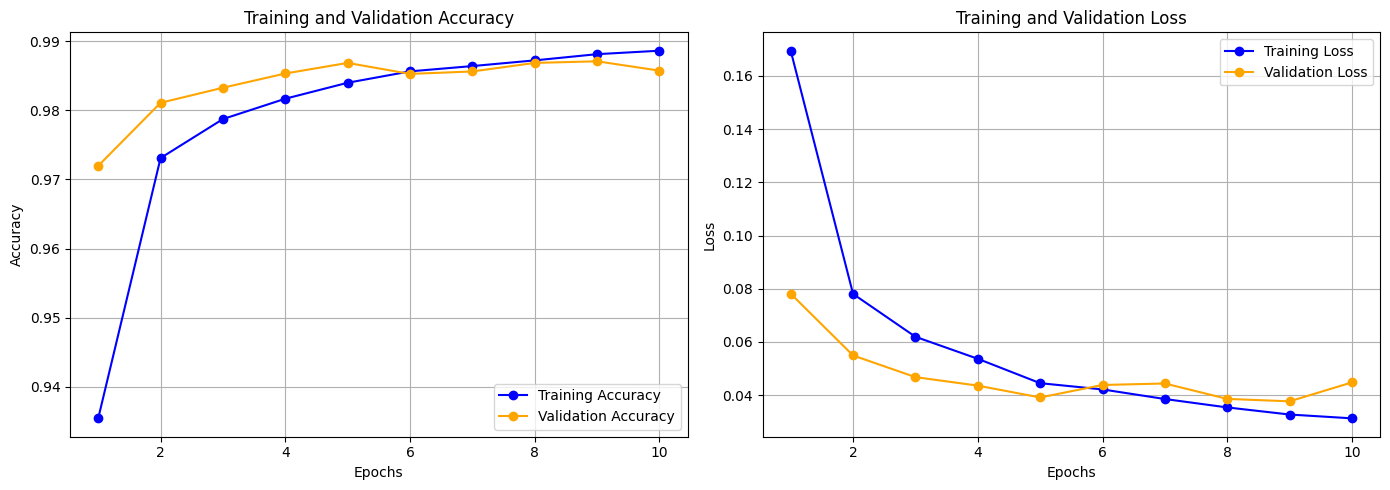

531/531 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step

--- Classification Report ---
                 precision    recall  f1-score   support

Closed (Drowsy)       0.99      0.98      0.99      8389
  Open (Active)       0.98      0.99      0.99      8591

       accuracy                           0.99     16980
      macro avg       0.99      0.99      0.99     16980
   weighted avg       0.99      0.99      0.99     16980



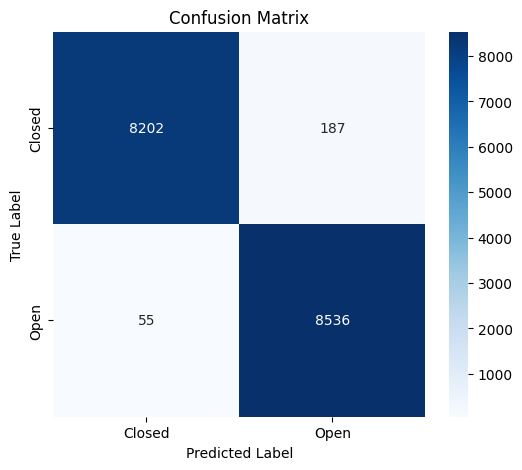

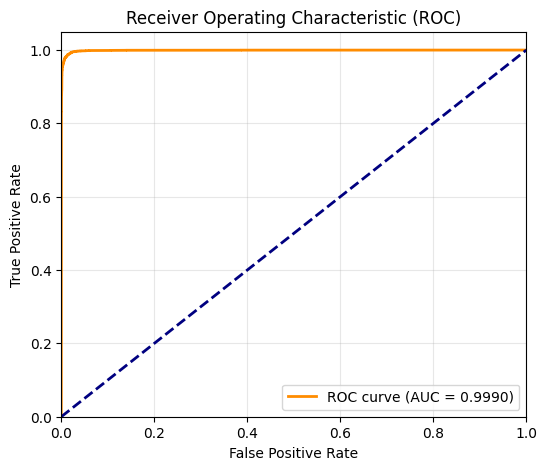

Exact AUC Value: 0.999007005684856


In [ ]:
def plot_training_history(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, val_gen, history=None):
    print("Evaluating Model...")

    # Plot history curves if available
    if history is not None:
        plot_training_history(history)

    # Get true labels
    y_true = val_gen.classes

    # Get predictions
    y_pred_prob = model.predict(val_gen)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # 1. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['Closed (Drowsy)', 'Open (Active)']))

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Closed', 'Open'],
                yticklabels=['Closed', 'Open'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # 3. ROC Curve and AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    # Changed : :.4f to see the exact precision
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3) # better visibility
    plt.show()


    print(f"Exact AUC Value: {roc_auc}")

evaluate_model(model, val_gen, history)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save to  Google Drive
model.save('/content/drive/MyDrive/drowsiness_eye_model.h5')
print("Model saved permanently to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved permanently to Google Drive!
